# **Deliverable 3: Data Visualization**

- Author: Tales Miguel Machado Pereira  
- RA: 140247
- Professor: Dr. Marcos Quiles

## A3 Instructions
- Use a subset of 5K molecules
- Use the MoleculeDescriptors of the RDKit
- Minimum of 100 descriptors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.rdMolDescriptors import *
from rdkit.ML.Descriptors import MoleculeDescriptors

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from tqdm.auto import tqdm
import random

### **2. Subset**

Load the QM9 dataset and select a subset of 5,000 molecules for analysis.

In [2]:
# Load QM9 dataset
qm9_df = pd.read_csv('qm9_complete_dataset.csv')
# Sample 5,000 molecules randomly for analysis
random.seed(42)
np.random.seed(42)

sample_size = 5000
if len(qm9_df) >= sample_size:
    qm9_sample = qm9_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
else:
    qm9_sample = qm9_df.copy()

# Validate SMILES in sample
valid_mols = []
valid_smiles = []
valid_indices = []

for idx, smiles in tqdm(enumerate(qm9_sample['canonical_smiles']), total=len(qm9_sample)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_mols.append(mol)
        valid_smiles.append(smiles)
        valid_indices.append(idx)

# Create final dataset with valid molecules
qm9_final = qm9_sample.iloc[valid_indices].reset_index(drop=True)

# Display sample statistics

# Show sample of the data
print(f"\nSample of selected molecules:")
print(qm9_final[['gdb_id', 'canonical_smiles']].head())

100%|██████████| 5000/5000 [00:00<00:00, 31332.95it/s]


Sample of selected molecules:
   gdb_id  canonical_smiles
0    3116      N#CC12CC1CO2
1  117880     COCC(O)C#CC=O
2   23434  COC1C2CC(=NO)C21
3   61956     C#CCOC(C)CC=O
4   98812   COC(=N)N1CCC1=N


### **3. Molecular descriptors Selection**

Calculate molecular descriptors using RDKit's descriptor library including 2D and 3D descriptors

In [3]:
descriptor_names = [desc[0] for desc in Descriptors.descList]
descriptor_calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

print(f"Total descriptors: {len(descriptor_names)}")
print(f"Processing {len(valid_mols)} molecules...")

descriptor_data = []
for mol in tqdm(valid_mols):
    descriptors = descriptor_calculator.CalcDescriptors(mol)
    descriptor_data.append(descriptors)

descriptors_df = pd.DataFrame(descriptor_data, columns=descriptor_names)
final_df = pd.concat([qm9_final.reset_index(drop=True), descriptors_df], axis=1)

print(f"Final dataset shape: {final_df.shape}")
print(f"Descriptors calculated: {len(descriptor_names)}")
print(descriptors_df.head())

Total descriptors: 217
Processing 5000 molecules...


100%|██████████| 5000/5000 [00:10<00:00, 473.60it/s]



Final dataset shape: (5000, 236)
Descriptors calculated: 217
   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0           8.311944        8.311944           0.263889       -0.263889   
1           9.588026        9.588026           0.139722       -0.847037   
2           8.328809        8.328809           0.371204        0.371204   
3           9.846767        9.846767           0.043009       -0.043009   
4           7.125972        7.125972           0.075231        0.075231   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.433162  53.857143   95.101          90.061   95.037114   
1  0.390787  11.333333  128.127         120.063  128.047344   
2  0.410929  50.333333  127.143         118.071  127.063329   
3  0.407324  12.000000  126.155         116.075  126.068080   
4  0.361711  17.000000  127.147         118.075  127.074562   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                   36  ...           0 

### **4. Dimensionality Reduction**

Applying three dimensionality reduction techniques: Feature Selection, Linear (PCA), and Nonlinear (Isomap)

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler

X = descriptors_df.values
X_clean = np.where(np.isfinite(X), X, 0)
zero_var_mask = np.var(X_clean, axis=0) != 0
X_filtered = X_clean[:, zero_var_mask] # cleaning 
feature_names_filtered = np.array(descriptor_names)[zero_var_mask]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

print(f"Original features: {len(descriptor_names)}")
print(f"After cleaning: {X_filtered.shape[1]}")

## Feature Selection (Pearson Correlation): Remove highly correlated features (threshold > 0.9)
corr_matrix = np.corrcoef(X_scaled.T)
to_remove = set()
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix[i, j]) > 0.9:
            to_remove.add(j)
            
remaining_indices = [i for i in range(X_scaled.shape[1]) if i not in to_remove]
X_uncorr = X_scaled[:, remaining_indices]
features_uncorr = feature_names_filtered[remaining_indices]

selected_indices = remaining_indices[:2]
X_selected = X_scaled[:, selected_indices]
selected_features = feature_names_filtered[selected_indices]

pca = PCA(n_components=2)  # 2 principal components
X_pca = pca.fit_transform(X_scaled)

isomap = Isomap(n_components=2, n_neighbors=10) # 10 neighbors
X_isomap = isomap.fit_transform(X_scaled)

print(f"Feature Selection: {X_selected.shape}")
print(f"PCA: {X_pca.shape}")
print(f"Isomap: {X_isomap.shape}")
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

print(f"\nSelected features for visualization:")
print(f"Feature 1 (X-axis): {selected_features[0]}")
print(f"Feature 2 (Y-axis): {selected_features[1]}")

print(f"\nPCA Component Analysis:")
pc1_loadings = pca.components_[0]
pc2_loadings = pca.components_[1]

pc1_top_features = np.argsort(np.abs(pc1_loadings))[-5:][::-1]
pc2_top_features = np.argsort(np.abs(pc2_loadings))[-5:][::-1]

print(f"PC1 - Top contributing features:")
for i, idx in enumerate(pc1_top_features):
    print(f"  {i+1}. {feature_names_filtered[idx]}: {pc1_loadings[idx]:.3f}")

print(f"PC2 - Top contributing features:")
for i, idx in enumerate(pc2_top_features):
    print(f"  {i+1}. {feature_names_filtered[idx]}: {pc2_loadings[idx]:.3f}")


Original features: 217
After cleaning: 183
Feature Selection: (5000, 2)
PCA: (5000, 2)
Isomap: (5000, 2)
PCA explained variance: 0.261

Selected features for visualization:
Feature 1 (X-axis): MaxAbsEStateIndex
Feature 2 (Y-axis): MinAbsEStateIndex

PCA Component Analysis:
PC1 - Top contributing features:
  1. Chi2v: 0.165
  2. Chi2n: 0.165
  3. Chi3v: 0.162
  4. Chi3n: 0.162
  5. Chi1n: 0.160
PC2 - Top contributing features:
  1. SMR_VSA1: 0.190
  2. BCUT2D_MRLOW: -0.188
  3. SlogP_VSA2: 0.176
  4. MolLogP: -0.162
  5. BCUT2D_LOGPLOW: -0.154
Feature Selection: (5000, 2)
PCA: (5000, 2)
Isomap: (5000, 2)
PCA explained variance: 0.261

Selected features for visualization:
Feature 1 (X-axis): MaxAbsEStateIndex
Feature 2 (Y-axis): MinAbsEStateIndex

PCA Component Analysis:
PC1 - Top contributing features:
  1. Chi2v: 0.165
  2. Chi2n: 0.165
  3. Chi3v: 0.162
  4. Chi3n: 0.162
  5. Chi1n: 0.160
PC2 - Top contributing features:
  1. SMR_VSA1: 0.190
  2. BCUT2D_MRLOW: -0.188
  3. SlogP_VSA2: 

### **5. Visualization**

Scatter plots colored by molecular properties and cluster labels

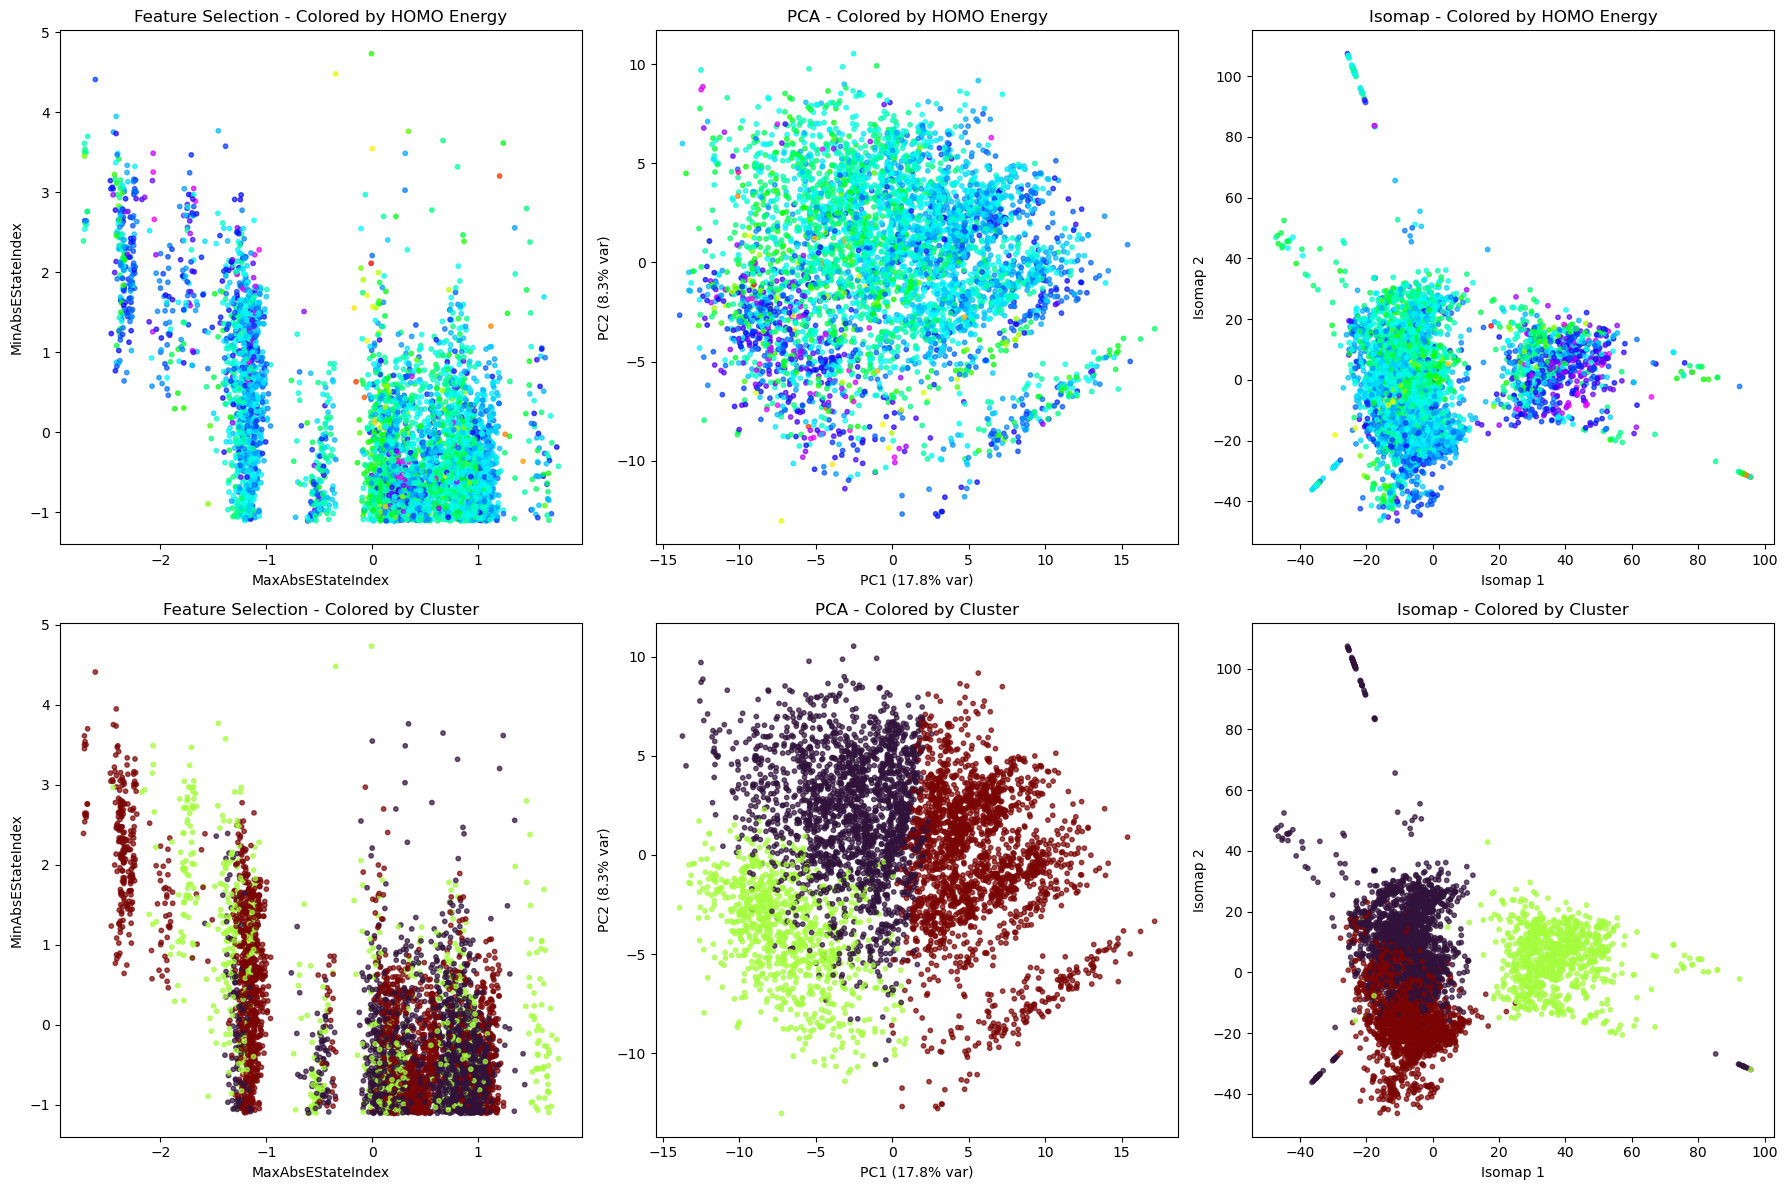

HOMO energy range: -0.352 to -0.134
Cluster distribution: [2072  867 2061]


In [5]:
homo_energy = qm9_final['homo_energy'].values
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0,0].scatter(X_selected[:, 0], X_selected[:, 1], c=homo_energy, cmap='hsv', alpha=0.7, s=10)
axes[0,0].set_title('Feature Selection - Colored by HOMO Energy')
axes[0,0].set_xlabel(f'{selected_features[0]}')
axes[0,0].set_ylabel(f'{selected_features[1]}')

axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], c=homo_energy, cmap='hsv', alpha=0.7, s=10)
axes[0,1].set_title('PCA - Colored by HOMO Energy')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

axes[0,2].scatter(X_isomap[:, 0], X_isomap[:, 1], c=homo_energy, cmap='hsv', alpha=0.7, s=10)
axes[0,2].set_title('Isomap - Colored by HOMO Energy')
axes[0,2].set_xlabel('Isomap 1')
axes[0,2].set_ylabel('Isomap 2')

axes[1,0].scatter(X_selected[:, 0], X_selected[:, 1], c=clusters, cmap='turbo', alpha=0.7, s=10)
axes[1,0].set_title('Feature Selection - Colored by Cluster')
axes[1,0].set_xlabel(f'{selected_features[0]}')
axes[1,0].set_ylabel(f'{selected_features[1]}')

axes[1,1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='turbo', alpha=0.7, s=10)
axes[1,1].set_title('PCA - Colored by Cluster')
axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

axes[1,2].scatter(X_isomap[:, 0], X_isomap[:, 1], c=clusters, cmap='turbo', alpha=0.7, s=10)
axes[1,2].set_title('Isomap - Colored by Cluster')
axes[1,2].set_xlabel('Isomap 1')
axes[1,2].set_ylabel('Isomap 2')

plt.tight_layout()
plt.show()

print(f"HOMO energy range: {homo_energy.min():.3f} to {homo_energy.max():.3f}")
print(f"Cluster distribution: {np.bincount(clusters)}")

### **6. Interpretation**

Analysis of dimensionality reduction techniques and molecular descriptor effectiveness

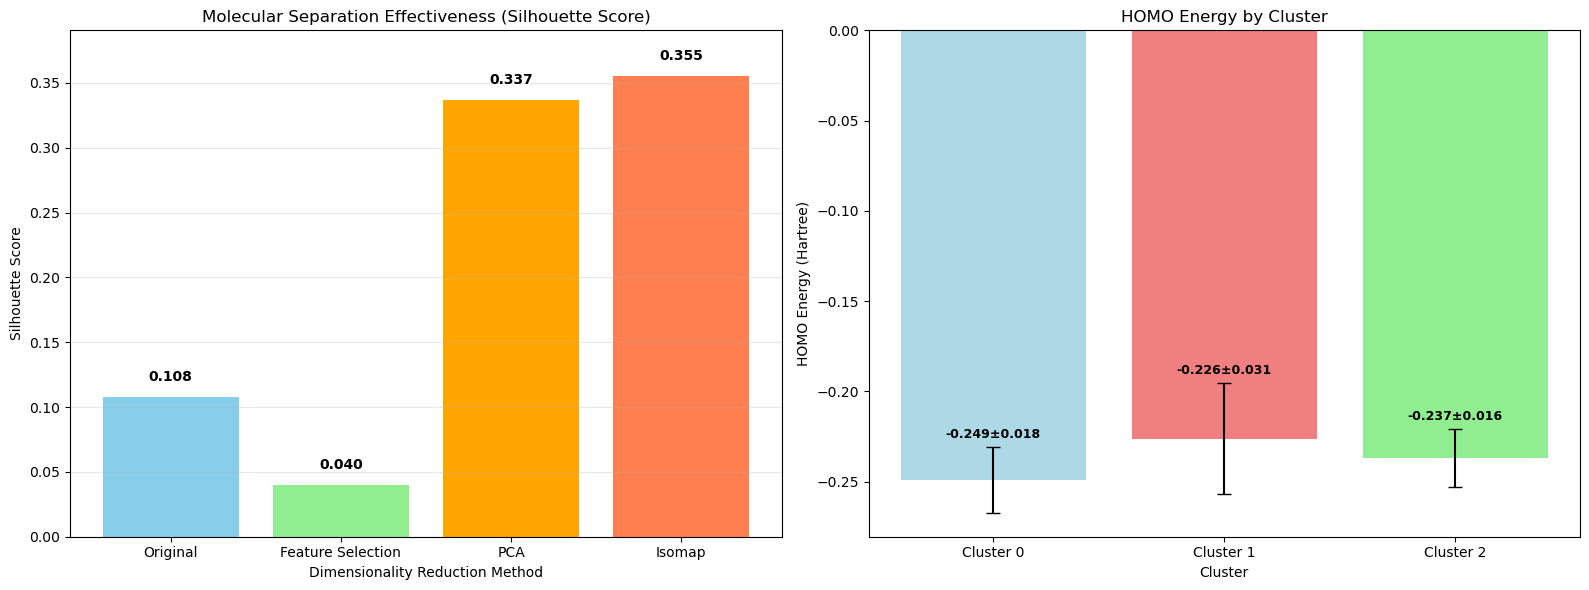

In [20]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil_original = silhouette_score(X_scaled, clusters)
sil_selected = silhouette_score(X_selected, clusters)
sil_pca = silhouette_score(X_pca, clusters)
sil_isomap = silhouette_score(X_isomap, clusters)

best_method = max([("Original", sil_original), ("Feature Selection", sil_selected), 
                   ("PCA", sil_pca), ("Isomap", sil_isomap)], key=lambda x: x[1])

pca_var_explained = pca.explained_variance_ratio_.sum()

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, f_oneway

sample_idx = np.random.choice(len(X_scaled), 500, replace=False)
orig_dist = pdist(X_scaled[sample_idx])
pca_dist = pdist(X_pca[sample_idx])
isomap_dist = pdist(X_isomap[sample_idx])

pca_corr = spearmanr(orig_dist, pca_dist)[0]
isomap_corr = spearmanr(orig_dist, isomap_dist)[0]

clusters_pca = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)
clusters_isomap = KMeans(n_clusters=3, random_state=42).fit_predict(X_isomap)
clusters_selected = KMeans(n_clusters=3, random_state=42).fit_predict(X_selected)

ari_pca = adjusted_rand_score(clusters, clusters_pca)
ari_isomap = adjusted_rand_score(clusters, clusters_isomap)
ari_selected = adjusted_rand_score(clusters, clusters_selected)

homo_by_cluster = [homo_energy[clusters == i] for i in range(3)]
f_stat, p_value = f_oneway(*homo_by_cluster)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Silhouette scores comparison
methods = ['Original', 'Feature Selection', 'PCA', 'Isomap']
scores = [sil_original, sil_selected, sil_pca, sil_isomap]

bars = ax1.bar(methods, scores, color=['skyblue', 'lightgreen', 'orange', 'coral'])
ax1.set_title('Molecular Separation Effectiveness (Silhouette Score)')
ax1.set_ylabel('Silhouette Score')
ax1.set_xlabel('Dimensionality Reduction Method')
ax1.set_ylim(0, max(scores) * 1.1)

for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

ax1.grid(axis='y', alpha=0.3)

# 2. HOMO energy distribution by cluster
cluster_means = [homo_energy[clusters == i].mean() for i in range(3)]
cluster_stds = [homo_energy[clusters == i].std() for i in range(3)]
x_pos = range(3)

ax2.bar(x_pos, cluster_means, yerr=cluster_stds, capsize=5, 
        color=['lightblue', 'lightcoral', 'lightgreen'])
ax2.set_title('HOMO Energy by Cluster')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('HOMO Energy (Hartree)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'Cluster {i}' for i in range(3)])
for i, (mean, std) in enumerate(zip(cluster_means, cluster_stds)):
    ax2.text(i, mean + std + 0.005, f'{mean:.3f}±{std:.3f}', 
             ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()